In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [23]:
# Load the data
df = pd.read_csv("sales.csv")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

In [24]:
print(df.head(35))

            sales
date             
2022-01-01   1200
2022-01-02    980
2022-01-03   1100
2022-01-04    870
2022-01-05    760
2022-01-06   1450
2022-01-07   1600
2022-01-08   1150
2022-01-09   1020
2022-01-10   1080
2022-01-11    930
2022-01-12    850
2022-01-13   1520
2022-01-14   1650
2022-01-15   1180
2022-01-16   1050
2022-01-17   1120
2022-01-18    960
2022-01-19    880
2022-01-20   1580
2022-01-21   1700
2022-01-22   1220
2022-01-23   1090
2022-01-24   1160
2022-01-25   1000
2022-01-26    920
2022-01-27   1620
2022-01-28   1750
2022-01-29   1260
2022-01-30   1130
2022-01-31   1200
2022-02-01   1050
2022-02-02    970
2022-02-03    860
2022-02-04   1480


In [25]:
df.shape

(365, 1)

# Decompose the series

In [26]:
# seasonal_decompose(): separates the series into its components mathematically

In [27]:
#  period = 7. It tells the function the length of one full seasonal cycle.

# df["sales"] -->Pass in pandas series with a DatetimeIndex. It must be a single column, not a dataframe
# model = "additive". It tells the function how the components combine. (Important)
result = seasonal_decompose(df["sales"], model="additive", period=7)

In [28]:
result

# What's inside result?

# result.observed --> The original series
# result.trend --> The trend component
# result.seasonal --> The seasonal component
# result.resid -->  The residual (noise)

# Each of them is a pandas series with the same DatetimeIndex ad my input

In [29]:
print(df.head(35))

            sales
date             
2022-01-01   1200
2022-01-02    980
2022-01-03   1100
2022-01-04    870
2022-01-05    760
2022-01-06   1450
2022-01-07   1600
2022-01-08   1150
2022-01-09   1020
2022-01-10   1080
2022-01-11    930
2022-01-12    850
2022-01-13   1520
2022-01-14   1650
2022-01-15   1180
2022-01-16   1050
2022-01-17   1120
2022-01-18    960
2022-01-19    880
2022-01-20   1580
2022-01-21   1700
2022-01-22   1220
2022-01-23   1090
2022-01-24   1160
2022-01-25   1000
2022-01-26    920
2022-01-27   1620
2022-01-28   1750
2022-01-29   1260
2022-01-30   1130
2022-01-31   1200
2022-02-01   1050
2022-02-02    970
2022-02-03    860
2022-02-04   1480


### Observed

In [32]:
result.observed.head(35)

date
2022-01-01    1200.0
2022-01-02     980.0
2022-01-03    1100.0
2022-01-04     870.0
2022-01-05     760.0
2022-01-06    1450.0
2022-01-07    1600.0
2022-01-08    1150.0
2022-01-09    1020.0
2022-01-10    1080.0
2022-01-11     930.0
2022-01-12     850.0
2022-01-13    1520.0
2022-01-14    1650.0
2022-01-15    1180.0
2022-01-16    1050.0
2022-01-17    1120.0
2022-01-18     960.0
2022-01-19     880.0
2022-01-20    1580.0
2022-01-21    1700.0
2022-01-22    1220.0
2022-01-23    1090.0
2022-01-24    1160.0
2022-01-25    1000.0
2022-01-26     920.0
2022-01-27    1620.0
2022-01-28    1750.0
2022-01-29    1260.0
2022-01-30    1130.0
2022-01-31    1200.0
2022-02-01    1050.0
2022-02-02     970.0
2022-02-03     860.0
2022-02-04    1480.0
Name: sales, dtype: float64

### Trend

In [36]:
result.trend.head(10)

date
2022-01-01            NaN
2022-01-02            NaN
2022-01-03            NaN
2022-01-04    1137.142857
2022-01-05    1130.000000
2022-01-06    1135.714286
2022-01-07    1132.857143
2022-01-08    1141.428571
2022-01-09    1154.285714
2022-01-10    1164.285714
Name: trend, dtype: float64

### Seasonal

In [39]:
result.seasonal.head(15)

date
2022-01-01    563.069382
2022-01-02    -54.381599
2022-01-03   -181.048265
2022-01-04   -156.384939
2022-01-05   -303.527796
2022-01-06   -339.591683
2022-01-07    471.864900
2022-01-08    563.069382
2022-01-09    -54.381599
2022-01-10   -181.048265
2022-01-11   -156.384939
2022-01-12   -303.527796
2022-01-13   -339.591683
2022-01-14    471.864900
2022-01-15    563.069382
Name: seasonal, dtype: float64

### Residual

In [40]:
result.resid.head(15)

date
2022-01-01           NaN
2022-01-02           NaN
2022-01-03           NaN
2022-01-04   -110.757919
2022-01-05    -66.472204
2022-01-06    653.877397
2022-01-07     -4.722043
2022-01-08   -554.497953
2022-01-09    -79.904115
2022-01-10     96.762551
2022-01-11    -85.043633
2022-01-12    -22.186490
2022-01-13    679.591683
2022-01-14     -7.579186
2022-01-15   -573.069382
Name: resid, dtype: float64

In [41]:
# Is the mean close to zero?
print(result.resid.mean())

-0.01616031027780837


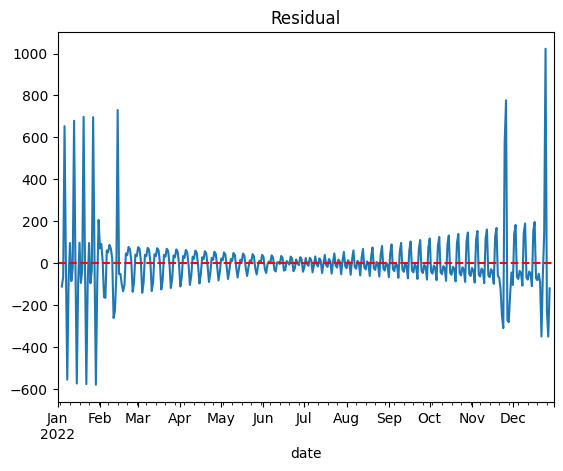

In [44]:
# Are there any large spikes
result.resid.plot(title="Residual")
plt.axhline(0, color='red', linestyle='--')  # reference line at zero
plt.show()

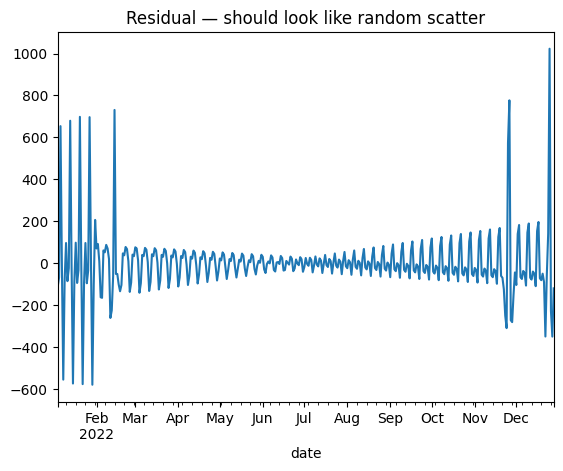

In [48]:
# Is there any remaining pattern
result.resid.dropna().plot(title='Residual — should look like random scatter')
plt.show()

# Plot for Seasonality, Residual, Trend, and original series

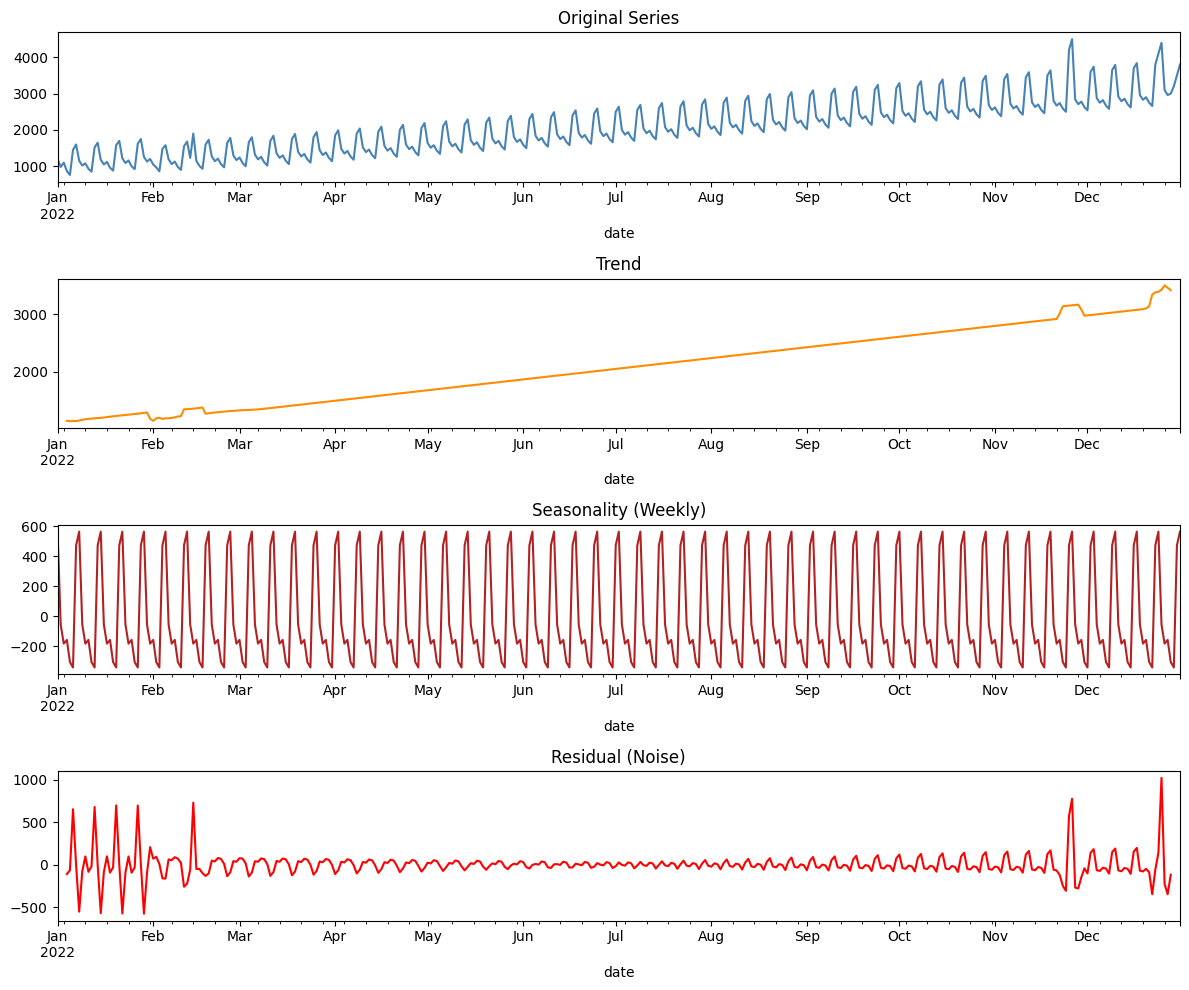

In [51]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

df["sales"].plot(ax=axes[0], title="Original Series", color="steelblue")
result.trend.plot(ax=axes[1], title="Trend", color="darkorange")
result.seasonal.plot(ax=axes[2], title="Seasonality (Weekly)", color="firebrick")
result.resid.plot(ax=axes[3], title="Residual (Noise)", color="Red")

plt.tight_layout()

### Reading the plots

In [55]:
# 1 - Original Series

# What you see: Starts around 1000 in January, ends around 3500–4000 in December. There are constant up-down spikes throughout the year forming a wave pattern.


# What to look for:
# Direction → Is it going up, down, or flat overall? Here it is clearly going upward — good, confirms a trend exists.

# Spike size over time → Are the waves getting bigger or staying the same size? Here the spikes are getting taller as the series grows — this is the tell-tale sign of multiplicative behavior. The weekend spikes in December are much larger than in January

# Any sudden jumps or drops → One-off events, data errors, or external shocks. You can spot the Black Friday and Christmas spikes if you look at Nov–Dec


# Your data insight: Upward trend + growing spike size = this series is more multiplicative than additive. We used model='additive' for learning purposes, but in a real project you would switch to model='multiplicative' here.

In [ ]:
# 2 - Trend

# What you see: A smooth, almost perfectly straight line going from ~1300 in January up to ~3300 in December. There is a small  bump/flatten around Feb-March and another around Nov-Dec.

# What to look for in any Trend plot:
# Shape → Linear (straight line) or nonlinear (curved)? Yours is almost perfectly linear — sales grew at a roughly constant rate all year
# Flat regions → A plateau in the trend means growth stalled during that period. You can see a slight flattening in Feb — possibly a post-January slowdown
# Sharp changes in direction → A sudden dip or spike in the trend (not the seasonal wiggles, but the smooth line itself) indicates a structural change — a new competitor, a major policy change, an economic shock. The slight uptick in Nov–Dec is the year-end sales push bleeding into the trend
# NaN edges → Notice the trend starts and ends slightly inward — those are the NaN values from the moving average we discussed

# Your data insight: Clean, consistent upward linear trend. No structural breaks. This is a healthy, predictable series — ideal for forecasting.

In [56]:
# Seasonality
# What you see: A perfectly repeating wave between roughly -200 and +500, cycling every 7 days across the entire year. The shape of each wave looks identical to every other wave.

# What to look for in any Seasonality plot:
# Amplitude (height of waves) → How strong is the seasonal effect? Your waves span from -200 to +500, meaning weekdays pull sales ~200 below trend and weekends push ~500 above. That is a significant seasonal effect
# Consistency → Do all waves look the same? In your plot they are perfectly identical — this is the fixed-pattern limitation of seasonal_decompose we discussed. Every week is treated as a carbon copy. STL would show slight variation
# Asymmetry → Are the peaks taller than the troughs are deep? Here peaks (+500) are larger than troughs (-200), meaning weekends boost more than weekdays hurt. This asymmetry itself is an insight — weekend demand is a strong driver
# Whether amplitude stays flat despite growing trend → In your plot the seasonal waves stay at the same height (-200 to +500) all year even though the trend doubled. This is actually the additive model forcing constant amplitude. In reality (multiplicative), the waves should be growing. This is one concrete sign additive was slightly the wrong choice here

# Your data insight: Strong, clear weekly seasonality. Weekend effect is real and significant. The flat amplitude across a growing trend suggests multiplicative would be more accurate.

In [ ]:
# Residual

# What you see: Mostly small fluctuations around zero from March onwards. But January and early February have noticeably large spikes (up to +600 and -500). There are also two large spikes near November–December (one reaching ~+800, one ~+1000, and a large negative ~-500).

# What to look for in any Residual plot:
# Is it centered around zero? → Yours is. Good. No systematic bias
# Are fluctuations roughly equal size throughout? → This is called homoscedasticity. Yours is not — January has much larger residuals than mid-year. This again points to the multiplicative nature of the data. When the trend was small, the additive model struggled more
# Large isolated spikes → These are your most valuable insights. They point to specific real-world events
# Any remaining wave pattern? → If residuals still wiggle in a regular pattern, seasonality was not fully removed. Your residuals from March–October look like clean random scatter — good. But Jan–Feb still has structure, which again is the additive/multiplicative mismatch

# Your data insight: Decomposition worked well for most of the year. The large residuals at the start and end are explainable — additive model mismatch at low values, and holiday events the model couldn't anticipate.

## Checking if decomposition worked

In [52]:
print(result.resid.describe())

count     359.000000
mean       -0.016160
std       148.424518
min      -578.783667
25%       -51.822883
50%        -7.579186
75%        38.002316
max      1022.953027
Name: resid, dtype: float64


In [53]:
print(f"\nResidual mean: {result.resid.mean():.2f}")   # should be near 0


Residual mean: -0.02


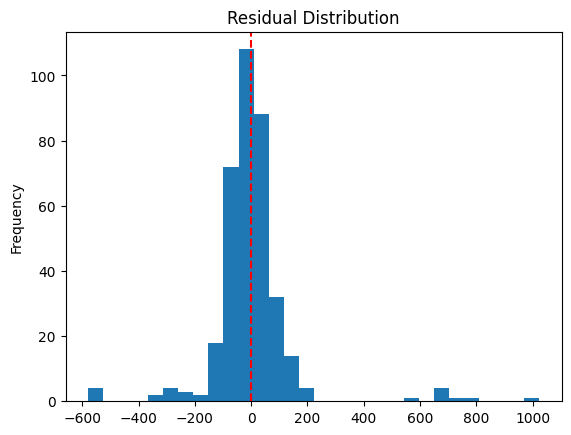

In [54]:
# Plot residual distribution — should look like a bell curve (normal)
result.resid.dropna().plot(kind='hist', bins=30, title='Residual Distribution')
plt.axvline(0, color='red', linestyle='--')  # reference line at zero
plt.show()